**Goal:** pick up exactly where L23 left off -- K-Means slicing two crescents in half -- and fix it
two ways. You will run **DBSCAN** (density-based) and watch it wrap the crescents that K-Means cut,
flag outliers as noise, and need no `k`; then build a **dendrogram** with agglomerative
hierarchical clustering and see how the **linkage** choice decides whether the crescents survive.
Pairs with the concept note [Hierarchical & Density-Based Clustering](l24_concept_hierarchical_dbscan.qmd).

> **Previously:** L23 -- K-Means Clustering & Similarity  |  **Next:** L25 -- Gaussian Mixtures & EM

> This page is the read-only view. To run the lab, open the notebook
> (`l24_lab_hierarchical_dbscan.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

We reuse the **exact two-moons dataset from L23** -- same `make_moons`, same seed, same noise. That
is the point: L23's K-Means scored ARI 0.239 on these crescents, and we want a strictly fair
rematch. ARI (the Adjusted Rand Index) is again our yardstick: 1.0 is a perfect match to the true
grouping, 0 is random. The data is **synthetic** (a fixed seed, identical for everyone) and 2-D so
every clustering is plottable.

## Setup

The setup is **two cells** (the pattern every lab uses). The first only installs; the second
imports, seeds, and rebuilds the L23 moons with the K-Means baseline.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, scipy, numpy and matplotlib, so this is effectively a no-op there.
%pip install -q scikit-learn scipy
# local, in a terminal (not in the notebook):  uv add scikit-learn scipy numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram

# The exact two crescents from L23 (same seed) -- so the before/after is honest.
X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)
km_ari = adjusted_rand_score(y, KMeans(n_clusters=2, random_state=42).fit(X).labels_)
print(f"L23 recap -- K-Means on the moons: ARI {km_ari:.3f}")

L23 recap -- K-Means on the moons: ARI 0.239


~~~text
L23 recap -- K-Means on the moons: ARI 0.239
~~~

## Step 1: DBSCAN Wraps the Crescents

K-Means failed because it groups by **distance to a center**, and a crescent has no usable center.
**DBSCAN** changes the definition: a cluster is a **dense, connected region**. It walks from point
to point through dense neighborhoods, so it follows each crescent around its curve. It takes two
knobs -- `eps` (how close counts as "neighbor") and `min_samples` (how many neighbors make a dense
"core" point) -- and **no `k`**. Run it on the same moons:

In [3]:
db = DBSCAN(eps=0.15, min_samples=5).fit(X)
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = int((db.labels_ == -1).sum())
print(f"DBSCAN: {n_clusters} clusters, {n_noise} noise points")
print(f"DBSCAN ARI vs the true crescents: {adjusted_rand_score(y, db.labels_):.3f}")
print(f"(same data, K-Means scored {km_ari:.3f})")

DBSCAN: 2 clusters, 0 noise points
DBSCAN ARI vs the true crescents: 1.000
(same data, K-Means scored 0.239)


~~~text
DBSCAN: 2 clusters, 0 noise points
DBSCAN ARI vs the true crescents: 1.000
(same data, K-Means scored 0.239)
~~~

DBSCAN found the two crescents **perfectly (ARI 1.000)** on the exact data where K-Means scored
0.239 -- and it was never told there were two clusters; it discovered that from the density. Plot
the result and the two arcs come out cleanly separated:

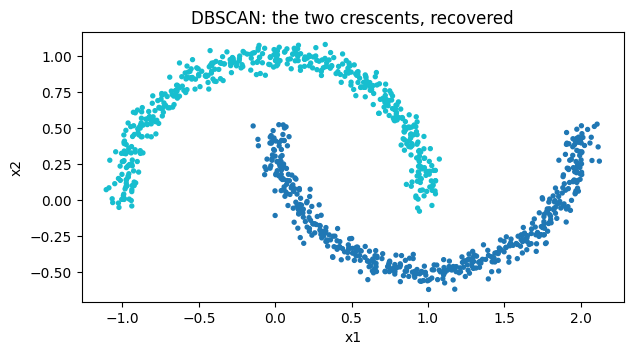

In [4]:
plt.figure(figsize=(7, 3.5))
plt.scatter(X[:, 0], X[:, 1], c=db.labels_, s=8, cmap="tab10")
plt.title("DBSCAN: the two crescents, recovered")
plt.xlabel("x1"); plt.ylabel("x2"); plt.show()

## Step 2: Noise, Core Points, and the eps Dial

DBSCAN sorts every point into one of three roles: a **core** point has at least `min_samples`
neighbors within `eps`; a **border** point is in a core point's neighborhood but is not itself
dense; a **noise** point is neither, and gets the label **-1**. That noise label is free **anomaly
detection** -- points in no dense region are flagged automatically. Inject 15 scattered outliers
into the moons and watch DBSCAN quarantine them:

In [5]:
rng = np.random.RandomState(42)
outliers = rng.uniform(low=[-1.5, -1.0], high=[2.5, 1.5], size=(15, 2))
X_out = np.vstack([X, outliers])
db2 = DBSCAN(eps=0.15, min_samples=5).fit(X_out)
n_out_clusters = len(set(db2.labels_)) - (1 if -1 in db2.labels_ else 0)
print(f"moons + 15 injected outliers: {n_out_clusters} clusters, "
      f"{int((db2.labels_ == -1).sum())} points flagged as noise (label -1)")
print(f"core points: {len(db2.core_sample_indices_)} of {len(X_out)}")

moons + 15 injected outliers: 2 clusters, 11 points flagged as noise (label -1)
core points: 1003 of 1015


~~~text
moons + 15 injected outliers: 2 clusters, 11 points flagged as noise (label -1)
core points: 1003 of 1015
~~~

DBSCAN kept the two crescents and flagged 11 of the 15 strays as noise (the other 4 happened to
land on a crescent). K-Means has no such option -- it would have forced every outlier into one of
its clusters. But DBSCAN lives and dies by `eps`. Sweep it to see the failure modes on either side
of a good value:

In [6]:
# Uncomment and complete: sweep eps to see the too-small / right / too-large behavior.
# for eps in (____, ____, ____):                          # try one tiny, one near 0.15, one large
#     lab = DBSCAN(eps=eps, min_samples=5).fit(X).labels_
#     nc = len(set(lab)) - (1 if -1 in lab else 0)
#     print(f"  eps={eps:.2f}: {nc} clusters, {int((lab == -1).sum())} noise, ARI {adjusted_rand_score(y, lab):.3f}")

<details><summary>Expected Output</summary>

~~~text
  eps=0.05: 7 clusters, 77 noise, ARI 0.306
  eps=0.15: 2 clusters, 0 noise, ARI 1.000
  eps=0.50: 1 clusters, 0 noise, ARI 0.000
~~~

The blank is `for eps in (0.05, 0.15, 0.50):`. Too **small** (0.05) and no neighborhood is dense
enough -- DBSCAN shatters the data into 7 fragments and dumps 77 points as noise. Too **large**
(0.50) and everything is one giant neighborhood -- a single cluster (ARI 0.000). The sweet spot
(0.15) recovers the two crescents exactly. `eps` is DBSCAN's `k`-equivalent decision, and it
**must be set on scaled features** -- one global distance threshold is meaningless if features are
on different scales.
</details>

## Step 3: Hierarchical Clustering and the Dendrogram

The other route to arbitrary shapes is **agglomerative hierarchical clustering**: start with every
point as its own cluster, then repeatedly **merge the two closest clusters** until one remains. The
full history of merges is a tree -- a **dendrogram** -- and you **cut** it at a height to choose how
many clusters you want. Build one on a tiny 12-point set so the tree is legible:

In [7]:
X_small, y_small = make_blobs(n_samples=12, centers=3, cluster_std=0.6, random_state=42)
Z = linkage(X_small, method="ward")
print("last 3 merge heights:", Z[-3:, 2].round(2))

agg = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X_small)
print("agglomerative k=3 ARI vs truth:", round(adjusted_rand_score(y_small, agg), 3))

last 3 merge heights: [ 1.98 19.6  34.19]
agglomerative k=3 ARI vs truth: 1.0


~~~text
last 3 merge heights: [ 1.98 19.6  34.19]
agglomerative k=3 ARI vs truth: 1.0
~~~

The last three merges jump from height 1.98 to 19.6 to 34.19 -- two big leaps. Those tall final
merges are the algorithm joining groups that are really far apart, so **cutting below them leaves 3
clusters**, which matches the truth exactly (ARI 1.0). The dendrogram shows this at a glance: cut
across the two long vertical lines and you get three branches.

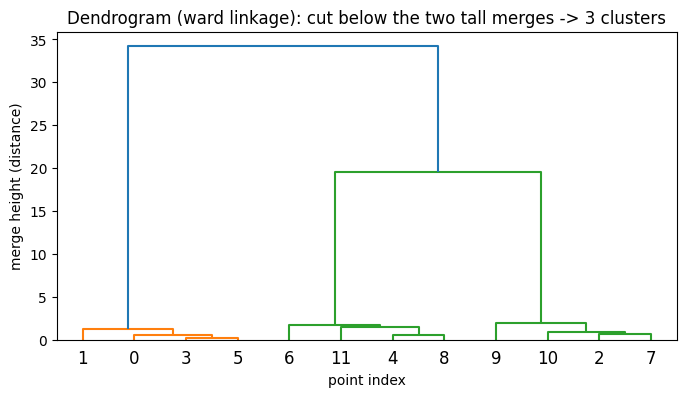

In [8]:
plt.figure(figsize=(8, 4))
dendrogram(Z)
plt.title("Dendrogram (ward linkage): cut below the two tall merges -> 3 clusters")
plt.xlabel("point index"); plt.ylabel("merge height (distance)")
plt.show()

## Step 4: Linkage Matters -- the Three-Way Bake-Off

"Merge the two closest clusters" hides a choice: closest **how**? That is the **linkage** rule.
**Single** linkage uses the nearest pair of points between two clusters, so it can chain along a
thin connected shape like a crescent. **Ward** linkage merges whichever pair least increases the
within-cluster variance, so it prefers compact, round blobs -- and cuts a crescent just like
K-Means. Put all four contenders on the moons:

In [9]:
results = {
    "K-Means (k=2)":          KMeans(n_clusters=2, random_state=42).fit(X).labels_,
    "DBSCAN (eps=0.15)":      DBSCAN(eps=0.15, min_samples=5).fit(X).labels_,
    "Agglomerative (single)": AgglomerativeClustering(n_clusters=2, linkage="single").fit_predict(X),
    "Agglomerative (ward)":   AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(X),
}
for name, lab in results.items():
    print(f"  {name:24s} ARI {adjusted_rand_score(y, lab):.3f}")

  K-Means (k=2)            ARI 0.239
  DBSCAN (eps=0.15)        ARI 1.000
  Agglomerative (single)   ARI 1.000
  Agglomerative (ward)     ARI 0.150


~~~text
  K-Means (k=2)            ARI 0.239
  DBSCAN (eps=0.15)        ARI 1.000
  Agglomerative (single)   ARI 1.000
  Agglomerative (ward)     ARI 0.150
~~~

Two winners and two losers, and the split is about **shape, not effort**. DBSCAN (density) and
single-linkage hierarchical (nearest-pair chaining) both wrap the crescents perfectly. K-Means
(centroid) and **ward** linkage (compact blobs) both cut them in half -- ward's 0.150 is essentially
K-Means' 0.239 in a different costume. The lesson of Unit VI in one table: **match the algorithm to
the shape of your clusters.**

## Your Turn

### Exercise 1 -- DBSCAN on nested rings

Here are two concentric rings (`make_circles`) -- an even harder shape than the moons. K-Means is
printed for you; it is helpless. Cluster the rings with DBSCAN and recover both.

In [10]:
X_ring, y_ring = make_circles(n_samples=1000, noise=0.05, factor=0.5, random_state=42)
print("rings:", X_ring.shape, "-- K-Means ARI:",
      round(adjusted_rand_score(y_ring, KMeans(n_clusters=2, random_state=42).fit(X_ring).labels_), 3))

rings: (1000, 2) -- K-Means ARI: -0.001


~~~text
rings: (1000, 2) -- K-Means ARI: -0.001
~~~

**Hint:** fit `DBSCAN(eps=0.15, min_samples=5)` on `X_ring`; count clusters from `labels_` (exclude -1) and print `adjusted_rand_score(y_ring, labels_)`.

In [11]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
DBSCAN eps=0.15: 2 clusters, ARI 1.0
~~~

K-Means scores ARI -0.001 -- worse than a coin flip, because the two rings share the same center, so
no centroid split can separate them. DBSCAN ignores centers entirely and walks each ring's dense
band, recovering both perfectly (ARI 1.0). Concentric structure is invisible to a centroid method
and obvious to a density method.
</details>

### Exercise 2 -- Linkage face-off on the rings

Now cluster the same rings with agglomerative hierarchical clustering, **single** versus **ward**
linkage, and report both ARIs. Which linkage follows a ring, and why?

In [12]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
  linkage=single  ARI 1.000
  linkage=ward    ARI 0.004
~~~

Single linkage scores **1.000**, ward **0.004**. Single linkage merges on the nearest pair of
points, so it chains all the way around each ring's connected band -- exactly the trick that wrapped
the moons. Ward insists on compact, low-variance blobs, so it carves the rings into pie slices and
fails (0.004), just as it did on the crescents. The same single-vs-ward split holds across every
non-convex shape: connected structure needs a connected-by-design rule.
</details>

## Summary

- K-Means cut the L23 crescents (ARI 0.239) because it clusters by distance to a center; **DBSCAN**
  clusters by **connected density** and wrapped them perfectly (ARI 1.000) with no `k`.
- DBSCAN sorts points into **core / border / noise (label -1)**, giving free **anomaly detection**
  (11 of 15 injected outliers flagged); its one critical dial is **`eps`** -- too small shatters into
  noise, too large merges into one blob.
- **Agglomerative** clustering merges the two closest clusters into a **dendrogram** you **cut** to
  pick `k`; the 12-point tree's two tall final merges marked 3 clusters (ARI 1.0).
- **Linkage** decides everything for non-round shapes: **single** linkage chains along crescents and
  rings (ARI 1.000), **ward** makes compact blobs and cuts them (0.150 on moons, 0.004 on rings) --
  ward is K-Means' twin.
- Match the algorithm to the shape: centroids for round blobs, **density (DBSCAN)** or
  **single-linkage** for connected arbitrary shapes, a **dendrogram** when you want the whole merge
  tree.
- Next (L25): Gaussian mixtures and EM -- soft, probabilistic clustering that assigns each point a
  membership probability rather than a single hard label. This closes Unit VI's clustering trio.